# Benchmark Figures — DUC, DUC-S, DUC-M

Reads pre-aggregated CSVs from `../experiments/experiment_results_duc/`.  
Generates two sets of 4 figures:
- **DUC + DUC-S** only  
- **DUC + DUC-S + DUC-M**

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = '../experiments/experiment_results_duc'

plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.size':         13,
    'axes.titlesize':    14,
    'axes.labelsize':    13,
    'legend.fontsize':   12,
    'xtick.labelsize':   11,
    'ytick.labelsize':   11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.35,
    'grid.linestyle':    '--',
})

COLORS  = {'DUC': '#1397b4', 'DUCT': '#4285f4', 'DUCM': '#9900ff'}
MARKERS = {'DUC': 'o',       'DUCT': 's',        'DUCM': '^'}


def plot_duc_benchmark(csv_file, x_col, xlabel, title, out_name, algorithms):
    """Plot avg_elapsed ± std_elapsed for the given algorithm subset and save as PNG."""
    df = pd.read_csv(os.path.join(RESULTS_DIR, csv_file))
    df = df[df['algorithm'].isin(algorithms)]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    for alg, grp in df.groupby('algorithm'):
        grp = grp.sort_values(x_col)
        ax.plot(grp[x_col], grp['avg_elapsed'],
                marker=MARKERS[alg], color=COLORS[alg],
                linewidth=1.8, markersize=5, label=alg)
        ax.fill_between(grp[x_col],
                         (grp['avg_elapsed'] - grp['std_elapsed']).clip(lower=0),
                         grp['avg_elapsed'] + grp['std_elapsed'],
                         alpha=0.15, color=COLORS[alg])

    ax.set_xlabel(xlabel)
    ax.set_ylabel('mean runtime (s)')
    ax.set_title(title)
    ax.legend(framealpha=0.9)

    plt.tight_layout()
    out_path = os.path.join(RESULTS_DIR, out_name)
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved → {out_path}')

---
## DUC vs DUC-S

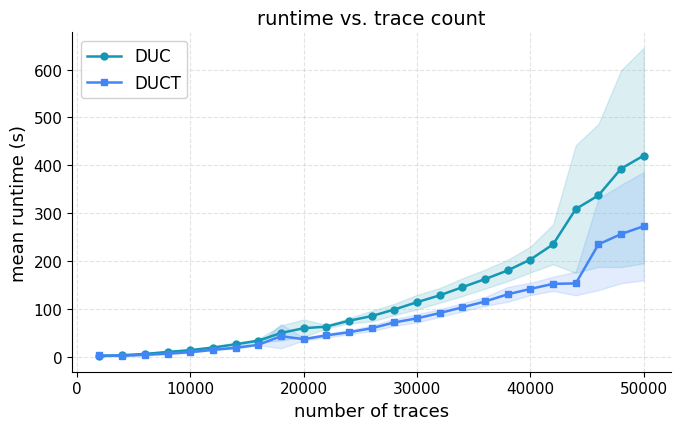

Saved → ../experiments/experiment_results_duc/fig_duc_ducs_trace_count.png


In [2]:
plot_duc_benchmark(
    csv_file   = 'avg_sample_size_results.csv',
    x_col      = 'sample_size',
    xlabel     = 'number of traces',
    title      = 'runtime vs. trace count',
    out_name   = 'fig_duc_ducs_trace_count.png',
    algorithms = ['DUC', 'DUCT'],
)

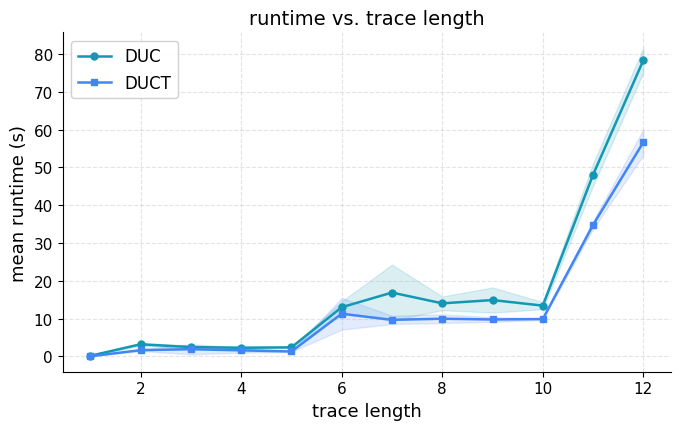

Saved → ../experiments/experiment_results_duc/fig_duc_ducs_trace_length.png


In [3]:
plot_duc_benchmark(
    csv_file   = 'avg_trace_length_results.csv',
    x_col      = 'trace_length',
    xlabel     = 'trace length',
    title      = 'runtime vs. trace length',
    out_name   = 'fig_duc_ducs_trace_length.png',
    algorithms = ['DUC', 'DUCT'],
)

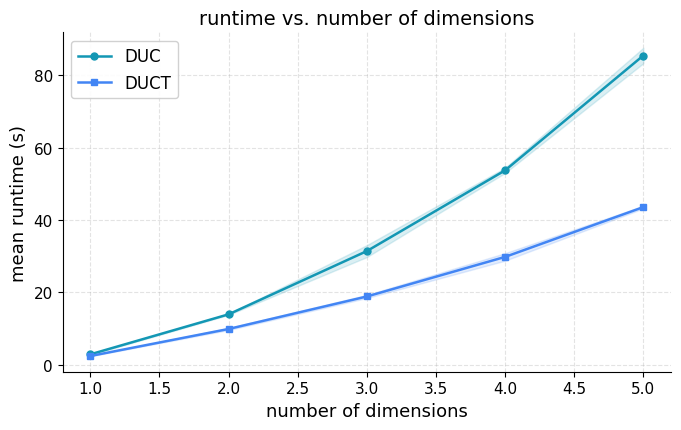

Saved → ../experiments/experiment_results_duc/fig_duc_ducs_dimensions.png


In [5]:
plot_duc_benchmark(
    csv_file   = 'avg_dimension_results.csv',
    x_col      = 'event_dimension',
    xlabel     = 'number of dimensions',
    title      = 'runtime vs. number of dimensions',
    out_name   = 'fig_duc_ducs_dimensions.png',
    algorithms = ['DUC', 'DUCT'],
)

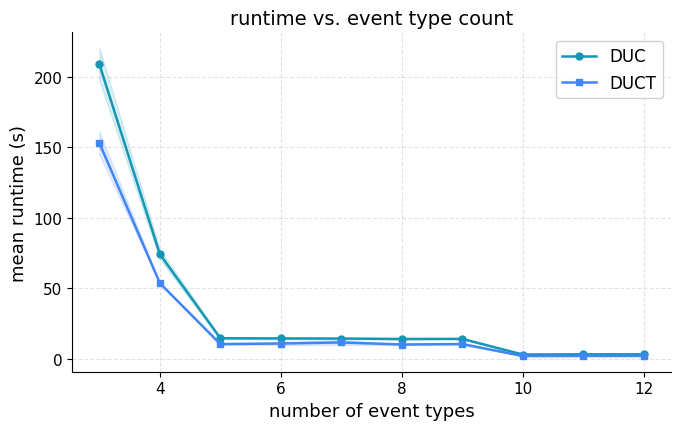

Saved → ../experiments/experiment_results_duc/fig_duc_ducs_type_count.png


In [4]:
plot_duc_benchmark(
    csv_file   = 'avg_type_count_results.csv',
    x_col      = 'type_count',
    xlabel     = 'number of event types',
    title      = 'runtime vs. event type count',
    out_name   = 'fig_duc_ducs_type_count.png',
    algorithms = ['DUC', 'DUCT'],
)

---
## DUC vs DUC-S vs DUC-M

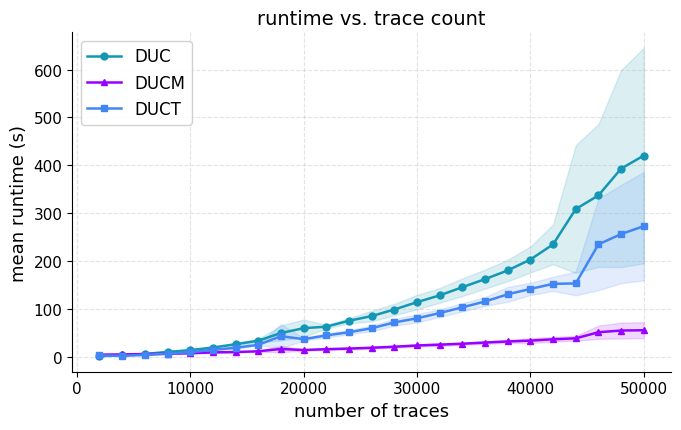

Saved → ../experiments/experiment_results_duc/fig_ducm_trace_count.png


In [6]:
plot_duc_benchmark(
    csv_file   = 'avg_sample_size_results.csv',
    x_col      = 'sample_size',
    xlabel     = 'number of traces',
    title      = 'runtime vs. trace count',
    out_name   = 'fig_ducm_trace_count.png',
    algorithms = ['DUC', 'DUCT', 'DUCM'],
)

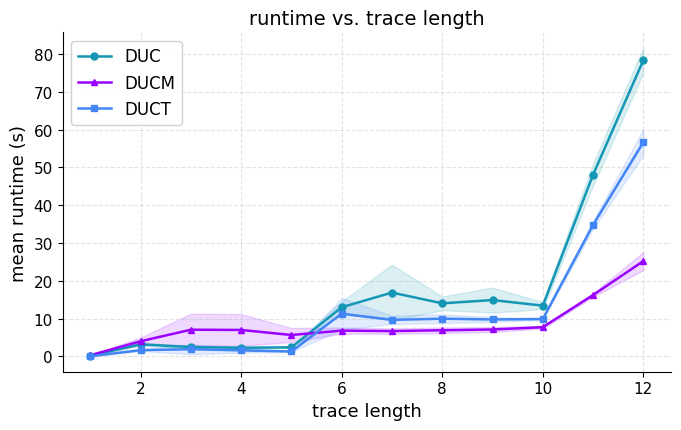

Saved → ../experiments/experiment_results_duc/fig_ducm_trace_length.png


In [7]:
plot_duc_benchmark(
    csv_file   = 'avg_trace_length_results.csv',
    x_col      = 'trace_length',
    xlabel     = 'trace length',
    title      = 'runtime vs. trace length',
    out_name   = 'fig_ducm_trace_length.png',
    algorithms = ['DUC', 'DUCT', 'DUCM'],
)

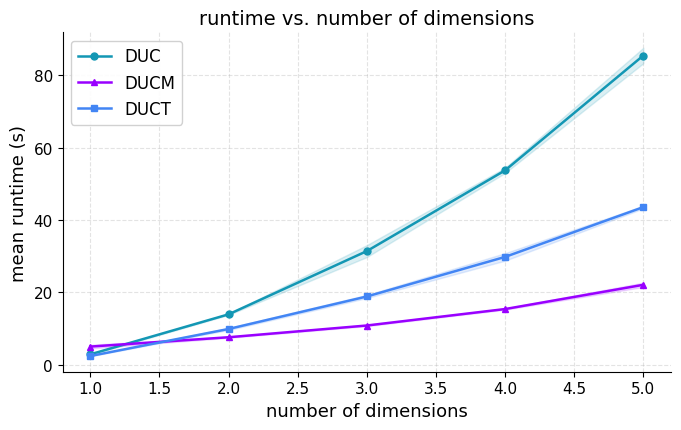

Saved → ../experiments/experiment_results_duc/fig_ducm_dimensions.png


In [8]:
plot_duc_benchmark(
    csv_file   = 'avg_dimension_results.csv',
    x_col      = 'event_dimension',
    xlabel     = 'number of dimensions',
    title      = 'runtime vs. number of dimensions',
    out_name   = 'fig_ducm_dimensions.png',
    algorithms = ['DUC', 'DUCT', 'DUCM'],
)

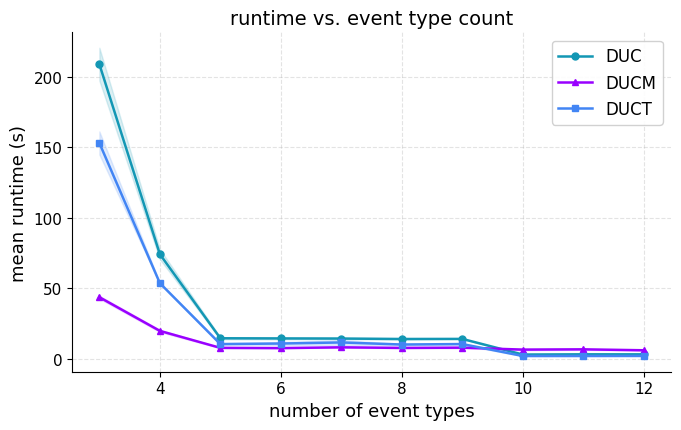

Saved → ../experiments/experiment_results_duc/fig_ducm_type_count.png


In [9]:
plot_duc_benchmark(
    csv_file   = 'avg_type_count_results.csv',
    x_col      = 'type_count',
    xlabel     = 'number of event types',
    title      = 'runtime vs. event type count',
    out_name   = 'fig_ducm_type_count.png',
    algorithms = ['DUC', 'DUCT', 'DUCM'],
)